<a href="https://colab.research.google.com/github/HooroBoy/Pemes/blob/main/JS06/JS06_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
	# import library
	import numpy as np
	import matplotlib.pyplot as plt
	from scipy import stats
	import seaborn as sns
	from sklearn.svm import SVC

In [2]:
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 36.3 MB/s eta 0:00:00


In [3]:
	# buat sebuah fungsi untuk menampilkan fitting data

	def plot_svc_decision_function(model, ax=None, plot_support=True):

	    if ax is None:
	        ax = plt.gca()
	    xlim = ax.get_xlim()
	    ylim = ax.get_ylim()

	    # buat grid untuk evaluasi model
	    x = np.linspace(xlim[0], xlim[1], 30)
	    y = np.linspace(ylim[0], ylim[1], 30)
	    Y, X = np.meshgrid(y, x)
	    xy = np.vstack([X.ravel(), Y.ravel()]).T
	    P = model.decision_function(xy).reshape(X.shape)

	    # plot batas dan margin
	    ax.contour(X, Y, P, colors='k',
	               levels=[-1, 0, 1], alpha=0.5,
	               linestyles=['--', '-', '--'])

	    # plot support vectors
	    if plot_support:
	        ax.scatter(model.support_vectors_[:, 0],
	                   model.support_vectors_[:, 1],
	                   s=300, linewidth=1, facecolors='none');
	    ax.set_xlim(xlim)
	    ax.set_ylim(ylim)

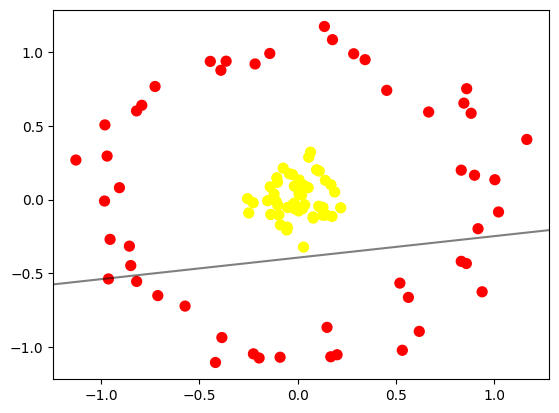

In [4]:
	# contoh data tidak terpisah secara linier
	from sklearn.datasets import make_circles
	X, y = make_circles(100, factor=.1, noise=.1)

	clf = SVC(kernel='linear').fit(X, y)

	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf, plot_support=False);

In [5]:
r = np.exp(-(X**2).sum(1))

In [6]:
	from mpl_toolkits import mplot3d
	from ipywidgets import interact, fixed

	def plot_3D(elev=30, azim=30, X=X, y=y):
	    ax = plt.subplot(projection='3d')
	    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
	    ax.view_init(elev=elev, azim=azim)
	    ax.set_xlabel('x')
	    ax.set_ylabel('y')
	    ax.set_zlabel('r')

	interact(plot_3D, elev=[-90, 45, 30, 20 , 10], azip=(-180, 180),
	         X=fixed(X), y=fixed(y))

interactive(children=(Dropdown(description='elev', index=2, options=(-90, 45, 30, 20, 10), value=30), IntSlide…

<function __main__.plot_3D(elev=30, azim=30, X=array([[-0.36321916,  0.93856366],
       [-0.0872966 , -0.17173094],
       [ 0.34333299,  0.94889341],
       [-0.24814299, -0.09028889],
       [-0.96823679,  0.29540469],
       [ 0.21935137, -0.05510231],
       [ 0.45330712,  0.74077723],
       [-0.19537825, -1.07326232],
       [ 0.0568861 ,  0.28762415],
       [-0.02424937, -0.03456237],
       [ 0.66632918,  0.59409509],
       [-0.72439746,  0.76718674],
       [ 0.02070202,  0.0309118 ],
       [ 0.56346288, -0.66255922],
       [ 0.84542688,  0.65418125],
       [-0.2243583 , -1.04518836],
       [-0.02581203,  0.17029599],
       [-0.22576992, -0.02089193],
       [-0.8180789 , -0.55445111],
       [-0.81859298,  0.60155023],
       [-1.12689418,  0.2685996 ],
       [ 0.17755597,  1.0844604 ],
       [-0.15203031, -0.00749129],
       [ 0.11933495, -0.05545353],
       [ 1.00299153,  0.13509904],
       [-0.97941845,  0.50676958],
       [ 0.06591223,  0.3218911 ],
       [-0.38475059, -0.93469272],
       [ 1.02151877, -0.08351494],
       [ 0.12891983, -0.10584951],
       [ 0.00729343,  0.03864917],
       [-0.10204606,  0.11800172],
       [ 0.88227776,  0.58542879],
       [-0.05470869, -0.20627361],
       [ 0.03034824, -0.3215984 ],
       [-0.14116027,  0.99085217],
       [ 0.20082376, -1.05134049],
       [ 0.28544773,  0.98879643],
       [ 0.0787205 , -0.1174729 ],
       [-0.08885815, -1.06809189],
       [ 0.1288734 , -0.05269098],
       [-0.96134738, -0.53730002],
       [ 0.02562253, -0.06061336],
       [ 0.17536332, -0.11352017],
       [ 0.61859226, -0.89296102],
       [ 0.14971199, -0.86567297],
       [ 0.8597123 ,  0.7520976 ],
       [-0.05028895, -0.05335079],
       [ 0.52011246, -0.56578936],
       [ 0.11012382,  0.19359909],
       [-0.9055346 ,  0.08105893],
       [ 1.16531754,  0.40806624],
       [ 0.14528206, -0.10435179],
       [-0.09542234, -0.10422161],
       [-0.01672202, -0.06123241],
       [-0.79193963,  0.63957411],
       [ 0.85788373, -0.43295173],
       [ 0.83212807, -0.41817775],
       [ 0.93827042, -0.62461254],
       [ 0.53252442, -1.02098027],
       [ 0.16979523,  0.10063924],
       [-0.07310779,  0.21350721],
       [ 0.03278128,  0.09554615],
       [ 0.03616771, -0.03493623],
       [-0.05225549, -0.18615138],
       [-0.4172802 , -1.10371965],
       [-0.05490859, -0.19383113],
       [ 0.00553119, -0.07668636],
       [-0.854991  , -0.31515961],
       [ 0.18876658,  0.05179051],
       [-0.84793488, -0.44668864],
       [-0.04149609,  0.17577438],
       [-0.57198231, -0.72150929],
       [-0.10814274, -0.01297951],
       [-0.95306379, -0.26917813],
       [-0.10538992,  0.14814694],
       [-0.11945122,  0.03794421],
       [-0.00496893, -0.04973436],
       [-0.01638748,  0.09145375],
       [ 0.89965337,  0.1654971 ],
       [-0.01771672, -0.02429196],
       [-0.25414925,  0.0063957 ],
       [ 0.00822539,  0.13280401],
       [-0.1360205 , -0.10034664],
       [ 0.05380368,  0.08136388],
       [ 0.83208326,  0.19988834],
       [-0.21603172,  0.91986039],
       [ 0.09686601,  0.20248969],
       [-0.389745  ,  0.8769971 ],
       [-0.13896578,  0.08682358],
       [ 0.10782045, -0.04469957],
       [-0.98134172, -0.00938848],
       [-0.10071473, -0.0373656 ],
       [ 0.16882496, -1.06506116],
       [ 0.1365038 ,  1.17381599],
       [ 0.14128711,  0.13030919],
       [-0.71040836, -0.6504498 ],
       [-0.44355043,  0.93716414],
       [ 0.07966817, -0.12502435],
       [ 0.91739786, -0.19709706]]), y=array([0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0]))>

In [7]:
	clf = SVC(kernel='rbf', C=1E6)
	clf.fit(X, y)

SVC(C=1000000.0)

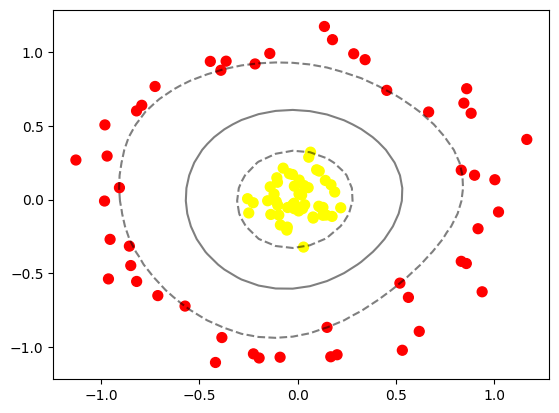

In [8]:
	plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
	plot_svc_decision_function(clf)
	plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
	            s=300, lw=1, facecolors='none')